# Category inflow heatmap (Seaborn)
Months on X-axis, fund categories on Y-axis, net inflow as colour intensity.

In [1]:
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- repo-root detection (works from any notebook working directory) ---
_HERE = Path(__file__).resolve() if '__file__' in globals() else Path.cwd()

def _find_repo_root(start: Path) -> Path:
    cand = start
    for _ in range(10):
        if (cand / 'Data' / 'processed' / 'category_inflows_clean.csv').exists():
            return cand
        if cand.name == 'notebooks':
            parent = cand.parent
            if (parent / 'Data' / 'processed' / 'category_inflows_clean.csv').exists():
                return parent
        cand = cand.parent
    return start.parent

_REPO_ROOT = _find_repo_root(_HERE)
DATA_PATH = _REPO_ROOT / 'Data' / 'processed' / 'category_inflows_clean.csv'

if not DATA_PATH.exists():
    raise FileNotFoundError(f'Missing file: {DATA_PATH.resolve()}')

df = pd.read_csv(DATA_PATH)
df['month_dt'] = pd.to_datetime(df['month'], format='%Y-%m', errors='coerce')
df['net_inflow_crore'] = pd.to_numeric(df['net_inflow_crore'], errors='coerce')
df = df.dropna(subset=['month_dt', 'category', 'net_inflow_crore']).copy()

# Keep month strings for labeling, but sort by datetime
month_order = (
    df[['month', 'month_dt']]
    .drop_duplicates()
    .sort_values('month_dt')['month']
    .tolist()
)

# Pivot to matrix: rows=category, cols=month
heatmap_df = (
    df.pivot_table(
        index='category',
        columns='month',
        values='net_inflow_crore',
        aggfunc='sum'
    )
)

# Ensure consistent month order
heatmap_df = heatmap_df.reindex(columns=month_order)

sns.set_theme(style='white', context='talk')


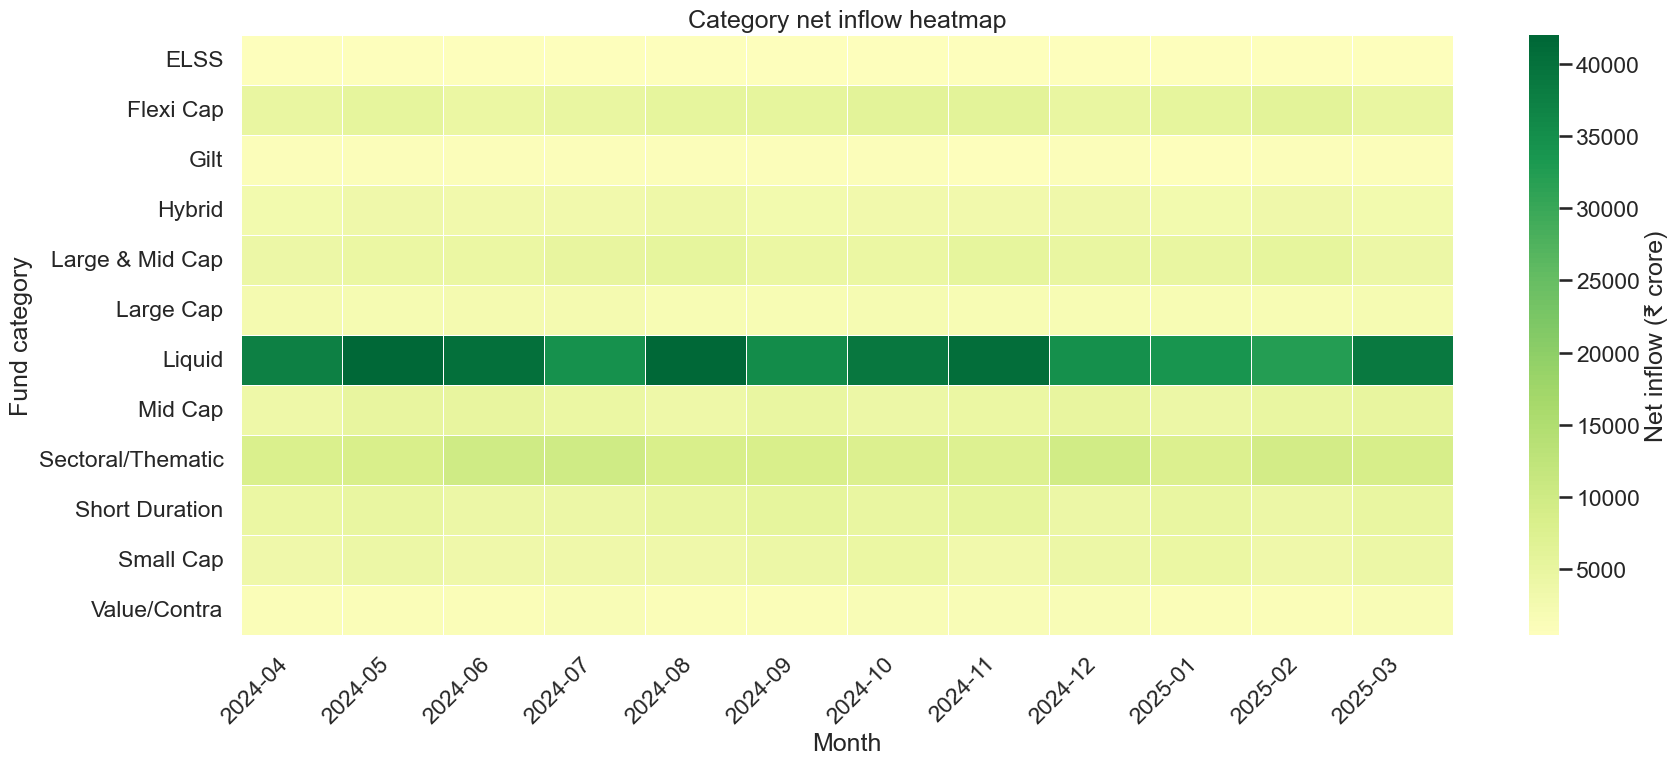

In [2]:
plt.figure(figsize=(18, 8))

ax = sns.heatmap(
    heatmap_df,
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Net inflow (₹ crore)'},
)

ax.set_xlabel('Month')
ax.set_ylabel('Fund category')
ax.set_title('Category net inflow heatmap')

# Rotate x tick labels for readability
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()
